# Modelación y Simulación 2026 - Lab 04
## Ejercicio 3: Modelo de asignación de horarios de autobuses (Ciudad de Guatemala)

Cada autobús que inicia turno $i$ ($x_i$) opera 8 horas continuas, cubriendo el periodo $i$ y el periodo $i+1$ (con envoltura circular: el turno 6 cubre el periodo 6 y el periodo 1 del día siguiente).

**Minimizar** $z = x_1+x_2+x_3+x_4+x_5+x_6$

**Sujeto a:**
$$x_6+x_1 \geq 4,\quad x_1+x_2 \geq 8,\quad x_2+x_3 \geq 10,\quad x_3+x_4 \geq 7,\quad x_4+x_5 \geq 12,\quad x_5+x_6 \geq 4$$
$$x_1,\dots,x_6 \geq 0$$

### 0. Instalar PuLP (solo la primera vez)
Descomenta la siguiente línea si no tienes PuLP instalado.

In [ ]:
# !pip install pulp


   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
    --------------------------------------- 0.3/16.4 MB ? eta -:--:--
   ------- -------------------------------- 3.1/16.4 MB 13.2 MB/s eta 0:00:02
   -------------- ------------------------- 5.8/16.4 MB 12.6 MB/s eta 0:00:01
   --------------------- ------------------ 8.9/16.4 MB 13.5 MB/s eta 0:00:01
   ------------------------------ --------- 12.6/16.4 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------  16.3/16.4 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 14.3 MB/s  0:00:01



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Importar librerías

In [2]:
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus, value
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


### 2. Datos del problema

In [ ]:
periodos = [1, 2, 3, 4, 5, 6]

# Horarios de los turnos (8 horas cada uno, segun Tabla 1 del enunciado)
turno_horarios = {
    1: "00:00-08:00",
    2: "04:00-12:00",
    3: "08:00-16:00",
    4: "12:00-20:00",
    5: "16:00-24:00",
    6: "20:00-04:00",
}

# Horarios de los periodos de demanda (4 horas cada uno)
periodo_horarios = {
    1: "00:00-04:00",
    2: "04:00-08:00",
    3: "08:00-12:00",
    4: "12:00-16:00",
    5: "16:00-20:00",
    6: "20:00-24:00",
}

demanda = {1: 4, 2: 8, 3: 10, 4: 7, 5: 12, 6: 4}


### 3. Construcción del modelo en PuLP

In [4]:
modelo = LpProblem("Asignacion_Horarios_Buses", LpMinimize)

# Variables: x_i = cantidad de buses que inician turno i (continuas, >= 0)
x = {i: LpVariable(f"x{i}", lowBound=0) for i in periodos}

# Funcion objetivo: minimizar el total de autobuses
modelo += lpSum(x[i] for i in periodos), "Total_de_buses"

# Restricciones: la oferta debe cubrir la demanda en cada periodo j
# (el periodo j es cubierto por el turno j y por el turno j-1)
for j in periodos:
    anterior = 6 if j == 1 else j - 1
    modelo += (x[j] + x[anterior] >= demanda[j]), f"Demanda_periodo_{j}"


### 4. Resolver y mostrar resultados

In [ ]:
modelo.solve()

print("Estado:", LpStatus[modelo.status])
print(f"Total optimo de autobuses: {value(modelo.objective):.0f}\n")

x_vals = {i: x[i].value() for i in periodos}

print("Turno | Horario       | Buses que inician (x_i)")
for i in periodos:
    print(f"  {i}   | {turno_horarios[i]:<13} | {x_vals[i]:.0f}")

cobertura = {}
print("\nPeriodo | Horario       | Demanda | Buses en operacion | Holgura")
for j in periodos:
    anterior = 6 if j == 1 else j - 1
    cobertura[j] = x_vals[j] + x_vals[anterior]
    print(f"  {j}     | {periodo_horarios[j]:<13} | {demanda[j]:<7} | {cobertura[j]:<18.0f} | {cobertura[j]-demanda[j]:.0f}")


Estado: Optimal
Total optimo de autobuses: 26

Turno | Horario       | Buses que inician (x_i)
  1   | 00:00-04:00   | 0
  2   | 04:00-08:00   | 10
  3   | 08:00-12:00   | 0
  4   | 12:00-16:00   | 12
  5   | 16:00-20:00   | 0
  6   | 20:00-24:00   | 4

Periodo | Horario       | Demanda | Buses en operacion | Holgura
  1     | 00:00-04:00   | 4       | 4                  | 0
  2     | 04:00-08:00   | 8       | 10                 | 2
  3     | 08:00-12:00   | 10      | 10                 | 0
  4     | 12:00-16:00   | 7       | 12                 | 5
  5     | 16:00-20:00   | 12      | 12                 | 0
  6     | 20:00-24:00   | 4       | 4                  | 0


### 5. Gráfica: buses que inician cada turno ($x_i$)

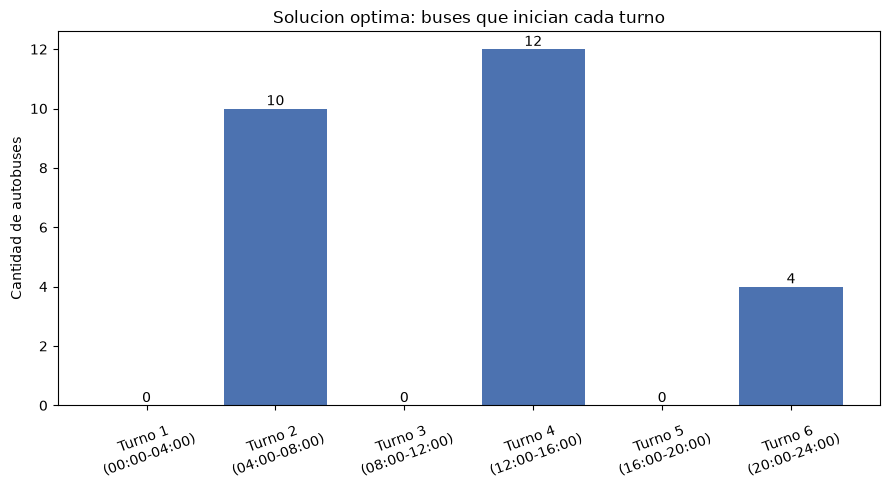

In [ ]:
etiquetas_turnos = [f"Turno {i}\n({turno_horarios[i]})" for i in periodos]
valores_x = [x_vals[i] for i in periodos]

plt.figure(figsize=(9, 5))
barras = plt.bar(etiquetas_turnos, valores_x, color="#4C72B0")
plt.bar_label(barras, fmt="%.0f")
plt.ylabel("Cantidad de autobuses")
plt.title("Solucion optima: buses que inician cada turno")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 6. Gráfica: demanda vs. buses en operación por periodo

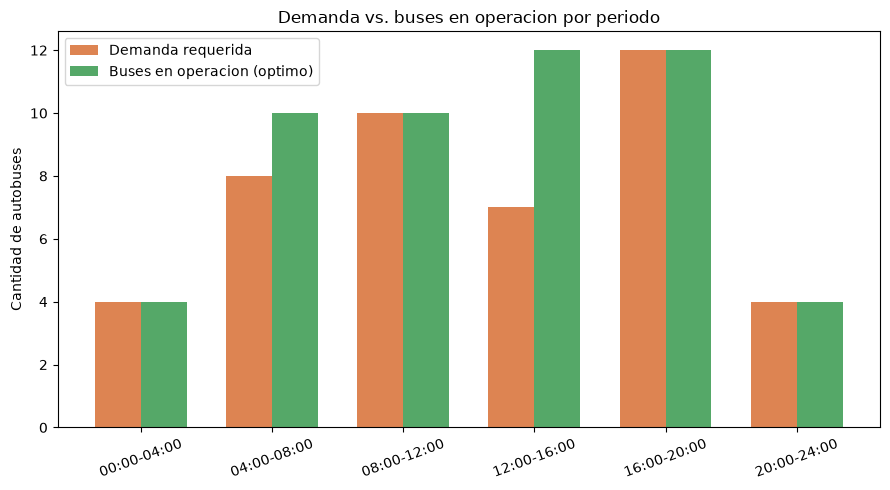

In [ ]:
etiquetas_periodos = [periodo_horarios[j] for j in periodos]
valores_demanda = [demanda[j] for j in periodos]
valores_cobertura = [cobertura[j] for j in periodos]

x_pos = np.arange(len(periodos))
ancho = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x_pos - ancho/2, valores_demanda, ancho, label="Demanda requerida", color="#DD8452")
plt.bar(x_pos + ancho/2, valores_cobertura, ancho, label="Buses en operacion (optimo)", color="#55A868")
plt.xticks(x_pos, etiquetas_periodos, rotation=20)
plt.ylabel("Cantidad de autobuses")
plt.title("Demanda vs. buses en operacion por periodo")
plt.legend()
plt.tight_layout()
plt.show()
